In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,auc
from sklearn.preprocessing import label_binarize

In [ ]:
iris=load_iris()
x=pd.DataFrame(iris.data,columns=iris.feature_names)
y=pd.Series(iris.target,name="target")

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
svm_model=SVC(kernel="rbf",C=1,gamma="scale",probability=True)
svm_model.fit(x_train,y_train)

SVC(C=1, probability=True)

In [ ]:
y_pred=svm_model.predict(x_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nclassification report:\n",classification_report(y_test,y_pred))

Accuracy: 1.0

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



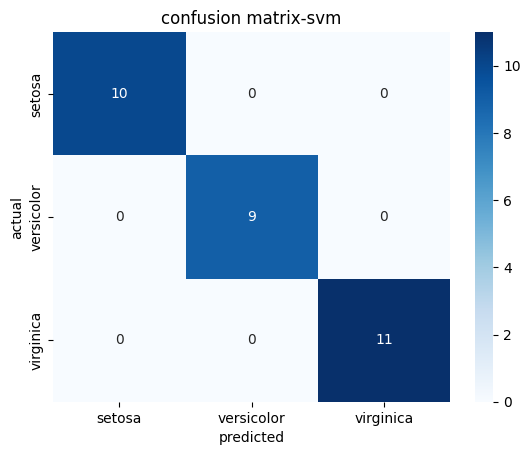

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.title("confusion matrix-svm")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

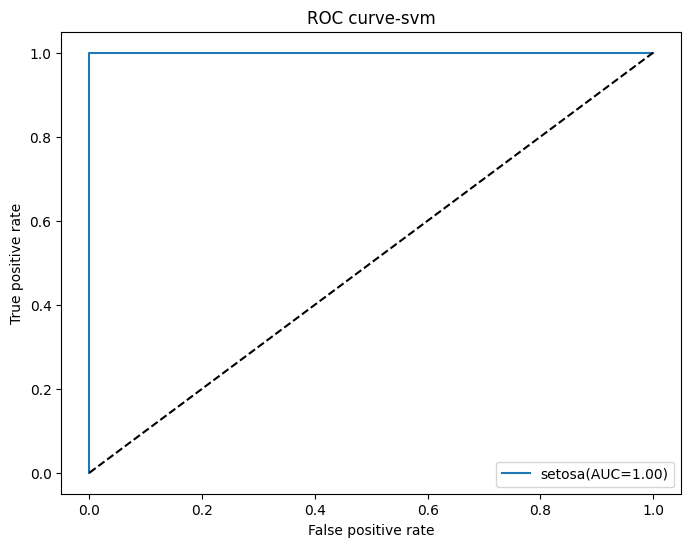

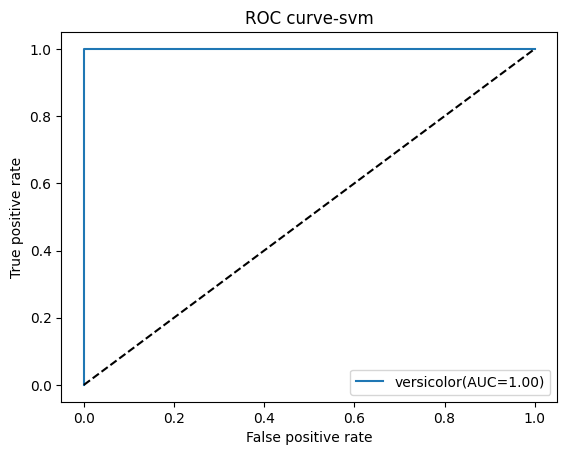

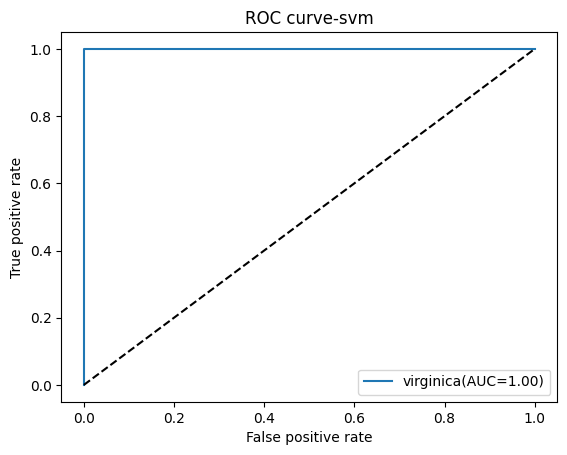

In [ ]:
y_test_bin=label_binarize(y_test,classes=[0,1,2])
y_score=svm_model.decision_function(x_test)
fpr,tpr,roc_auc={},{},{}
for i in range(3):
  fpr[i],tpr[i],_=roc_curve(y_test_bin[:,i],y_score[:,i])
  roc_auc[i]=auc(fpr[i],tpr[i])
  plt.figure(figsize=(8,6))
for i in range(3):
  plt.plot(fpr[i],tpr[i],label=f"{iris.target_names[i]}(AUC={roc_auc[i]:.2f})")
  plt.plot([0,1],[0,1],"k--")
  plt.title("ROC curve-svm")
  plt.xlabel("False positive rate")
  plt.ylabel("True positive rate")
  plt.legend()
  plt.show()